# Model comparison on evaluation set

In this notebook, we evaluate the different models' performance on the evaluation set, and compare with a baseline model. These models are:

- Baseline: a dummy classifier with stratified
- Logistic regressors (with and without synopsis embeddings)
- XGB ranker (with and without synopsis embeddings)
- LGBM ranked model

Each has been trained in Jupyter Notebook files found in the models folder.


In [1]:
import numpy as np
import csv
import pandas as pd
import json
import matplotlib.pyplot as plt
import sklearn
import sys
sys.path.append("../scripts")
from feature_engineering.feature_engineering import tag_dataframe

sys.path.append("../models")


In [4]:
## import test set
books_test = pd.read_csv('../data/books_engineered_test.csv')
books_test = books_test.copy()

print(books_test.shape)

# load in data with book_synopsis
books = pd.read_csv('../data/data_with_author_and_awards.csv',
dtype = {
    'isbn' : 'str', # do this explicitly to avoide getting a warning by the interpreter
    'author_birthyear' : 'Int64', # we have to explicitly do this to avoid pandas implicitly casting as float
    'title_id' : 'Int64'
},
)
books = books[books.release_year >= 2015]

(71935, 146)


In [6]:
books_test = pd.merge(books_test, books[['author', 'title', 'book_synopsis']], on=['author', 'title'])

In [ ]:
books_test.shape # validate the merge
                 # kind of crazy that we have as much data in the test set as there are in the training set

(71935, 147)

In [8]:
books_test.groupby('release_year')['target'].sum()

release_year
2015    13
2016    25
2017    24
2018    22
2019    24
2020    20
2021    21
2022    21
2023    20
2024    24
2025    20
Name: target, dtype: int64

In [9]:
model_results = {}

In [10]:
## import trained models
import joblib 

dummy_classifier = joblib.load('../models/trained_models/dummy_model.pkl')

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

dummy_pred = dummy_classifier.predict(books_test[features])

# books_test['dummy_pred'] = dummy_pred

from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score
from sklearn.metrics import precision_score, ndcg_score, recall_score, average_precision_score

model_results['dummy_classifier'] = {
    'f1_score': f1_score(books_test['target'], dummy_pred),
    'precision': precision_score(books_test['target'], dummy_pred),
    'recall': recall_score(books_test['target'], dummy_pred)

    # add more
}

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to 

In [11]:
# compare with baseline model of predicting books with previously-nominated authors

nom_pred = (books_test['NomineeBefore']).astype(int)

model_results['prior_nomination_baseline'] = {
    'f1_score': f1_score(books_test['target'], nom_pred),
    'precision': precision_score(books_test['target'], nom_pred),
    'recall': recall_score(books_test['target'], nom_pred)

    # add more
}

In [12]:
logistic_reg = joblib.load('../models/trained_models/logistic_model.pkl')

numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

## for logistic model, need to fill NaN values with dummy values
books_test_log = books_test.copy()
books_test_log['years_since_last_nomination'] = books_test_log['years_since_last_nomination'].fillna(99)
books_test_log['month_of_publication'] = books_test_log['month_of_publication'].fillna('Unknown')

logistic_proba = logistic_reg.predict_proba(books_test_log[features])[:, 1]

# recover the weighted mean threshold to use for classification: 
thresholds = logistic_reg.cv_results_['thresholds']
scores = logistic_reg.cv_results_['scores']

weighted_mean_threshold = np.average(thresholds, weights=scores)

logistic_pred = (logistic_proba > weighted_mean_threshold).astype(int)

# books_test['logistic_pred'] = logistic_pred

model_results['logistic_reg'] = {
    'f1_score': f1_score(books_test['target'], logistic_pred),
    'precision': precision_score(books_test['target'], logistic_pred),
    'recall': recall_score(books_test['target'], logistic_pred)
    # add more
}

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to 

In [13]:
xgbranker = joblib.load('../models/trained_models/xgbranker_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_ranking = xgbranker.predict(books_test[features])

books_test['xgb_rank_score'] = xgb_ranking

books_test['rank_within_year'] = books_test.groupby('release_year')['xgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (books_test['rank_within_year'] <= num_finalists).astype(int)
top10 = (books_test['rank_within_year'] <= 10).astype(int)
top15 = (books_test['rank_within_year'] <= 15).astype(int)
top20 = (books_test['rank_within_year'] <= 20).astype(int)
top100 = (books_test['rank_within_year'] <= 100).astype(int)

model_results['xgb_ranker'] = {
    'f1_score': f1_score(books_test['target'], topk),
    'precision': precision_score(books_test['target'], topk),
    'recall': recall_score(books_test['target'], topk),
    'precision@10': precision_score(books_test['target'], top10),
    'precision@15': precision_score(books_test['target'], top15),
    'precision@20': precision_score(books_test['target'], top20),
    # add more
}

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator SimpleImputer from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to 

In [51]:
xgbclassifier= joblib.load('../models/trained_models/xgbclassifier_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_predict = xgbclassifier.predict(books_test[features])

model_results['xgb_classifier'] = {
    'f1_score': f1_score(books_test['target'], xgb_predict),
    'precision': precision_score(books_test['target'], xgb_predict),
    'recall': recall_score(books_test['target'], xgb_predict),
    # add more
}

In [ ]:
# run if need to install lightgbm
#%conda install lightgbm 

2 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: linux-64
Solving environment: done


==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda



## Package Plan ##

  environment location: /home/tiger/anaconda3/envs/erdos_ds_environment

  added / updated specs:
    - lightgbm


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    lightgbm-4.6.0             |cpu_py312h67760b6_2         6.7 MB
    ------------------------------------------------------------
                                           Total:         6.7 MB

The following NEW packages will be INSTALLED:

  lightgbm           pkgs/main/linux-64::lightgbm-4.6.0-cpu_py312h67760b6_2 



                                                                                

In [18]:
# the pickled lgbm pipeline references bool_to_int from the training notebook,
# so it must be defined here before joblib.load can unpickle it
def bool_to_int(x):
    return x.astype(int)

lgbmranker = joblib.load('../models/trained_models/lgbmranker_model.pkl')

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

lgb_ranking = lgbmranker.predict(books_test[features])

books_test['lgb_rank_score'] = lgb_ranking

books_test['lgb_rank_within_year'] = books_test.groupby('release_year')['lgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (books_test['lgb_rank_within_year'] <= num_finalists).astype(int)
top10 = (books_test['lgb_rank_within_year'] <= 10).astype(int)
top15 = (books_test['lgb_rank_within_year'] <= 15).astype(int)
top20 = (books_test['lgb_rank_within_year'] <= 20).astype(int)

# NDCG@k, computed per year then averaged (as in models/lgbm_ranker.ipynb)
def mean_ndcg_at_k(data, score_column, k):
    ndcg_at_k_list = []
    for yr, grp in data.groupby('release_year'):
        y_true = grp['target'].values.astype(int)
        y_score = grp[score_column].values
        if y_true.sum() == 0:
            continue  # no finalists this year, metric undefined
        ndcg_at_k_list.append(ndcg_score([y_true], [y_score], k=k))
    return np.mean(ndcg_at_k_list)

model_results['lgbm_ranker'] = {
    'f1_score': f1_score(books_test['target'], topk),
    'precision': precision_score(books_test['target'], topk),
    'recall': recall_score(books_test['target'], topk),
    'precision@10': precision_score(books_test['target'], top10),
    'precision@15': precision_score(books_test['target'], top15),
    'precision@20': precision_score(books_test['target'], top20),
    'ndcg@k': mean_ndcg_at_k(books_test, 'lgb_rank_score', num_finalists),
    'ndcg@10': mean_ndcg_at_k(books_test, 'lgb_rank_score', 10),
    'ndcg@15': mean_ndcg_at_k(books_test, 'lgb_rank_score', 15),
    'ndcg@20': mean_ndcg_at_k(books_test, 'lgb_rank_score', 20),
    # add more
}

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


In [24]:
from feature_engineering.tagging_system import automate_tagging as at

transformer = at.load_transformer()

# we need to have two data sets here:
# one where we drop the n/a's and one without.
# the model will perform much worse without dropping the n/a's

test_set1 = books_test.copy()
test_set1.book_synopsis = test_set1.book_synopsis.apply(lambda x : '' if pd.isnull(x) else x)

test_set1['encoded_synopsis'] = test_set1.book_synopsis.apply(transformer.encode)

test_set2 = books_test.copy()
test_set2 = at.encode_books(test_set2, transformer)

In [48]:
# load in the SynopsisXGBRanker model

synopsis_xgb = joblib.load('../models/trained_models/xgbranker_with_synopsis_model.pkl') # pretty heavy to load

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

synopsis_features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features + ['encoded_synopsis'] # actually not needed in the model

synopsis_ranking = synopsis_xgb.predict(test_set1[synopsis_features]) # we can actually just plug in books_test here because the model pipeline drops all features on in the features list

# now we'll do the ranking system same as with xgb_ranker
test_set1['rank_score'] = synopsis_ranking

test_set1['rank_within_year'] = test_set1.groupby('release_year')['rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (test_set1['rank_within_year'] <= num_finalists).astype(int)
top10 = (test_set1['rank_within_year'] <= 10).astype(int)
top15 = (test_set1['rank_within_year'] <= 15).astype(int)
top20 = (test_set1['rank_within_year'] <= 20).astype(int)
top100 = (test_set1['rank_within_year'] <= 100).astype(int)



model_results['synopsis_xgb_ranker'] = {
    'f1_score': f1_score(books_test['target'], topk),
    'precision': precision_score(books_test['target'], topk),
    'recall': recall_score(books_test['target'], topk),
    'precision@10': precision_score(books_test['target'], top10),
    'precision@15': precision_score(books_test['target'], top15),
    'precision@20': precision_score(books_test['target'], top20),
    # add more if need
}

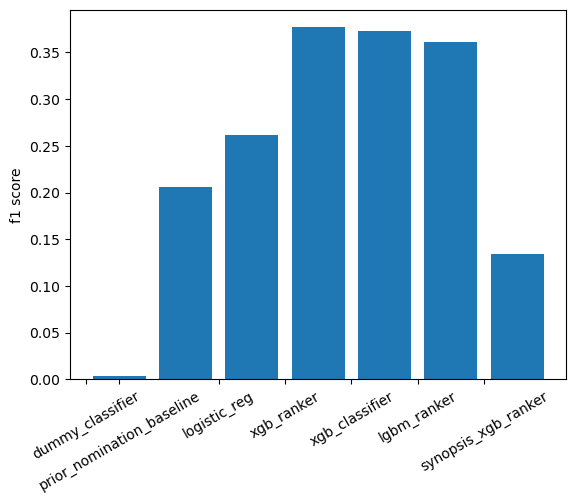

In [ ]:
plt.bar(np.arange(len(model_results)), [model['f1_score'] for model in model_results.values()])
plt.ylabel('f1 score')
plt.xticks(np.arange(len(model_results)) - 0.5 - 0.5 * np.array([0, 1, 0, 0 ,0 ,0, 0]), model_results.keys(), rotation=30,)
plt.show()

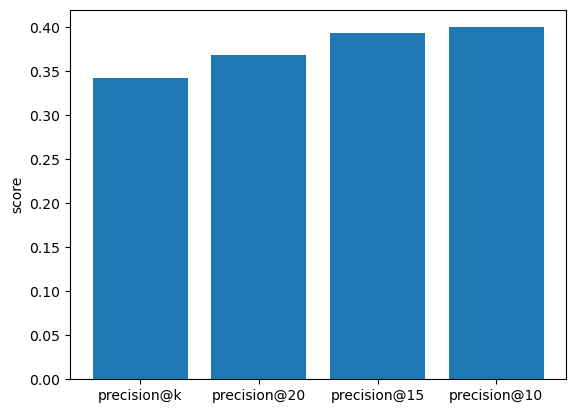

In [50]:
plt.bar(['precision@k', 'precision@20', 'precision@15', 'precision@10'],
    [model_results['xgb_ranker'][p] for p in ['precision', 'precision@20', 'precision@15', 'precision@10']]
)
plt.ylabel('score')
plt.show()

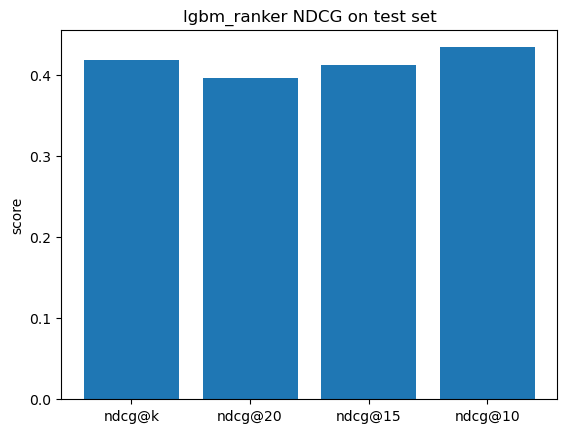

In [37]:
plt.bar(['ndcg@k', 'ndcg@20', 'ndcg@15', 'ndcg@10'],
    [model_results['lgbm_ranker'][n] for n in ['ndcg@k', 'ndcg@20', 'ndcg@15', 'ndcg@10']]
)
plt.ylabel('score')
plt.title('lgbm_ranker NDCG on test set')
plt.show()

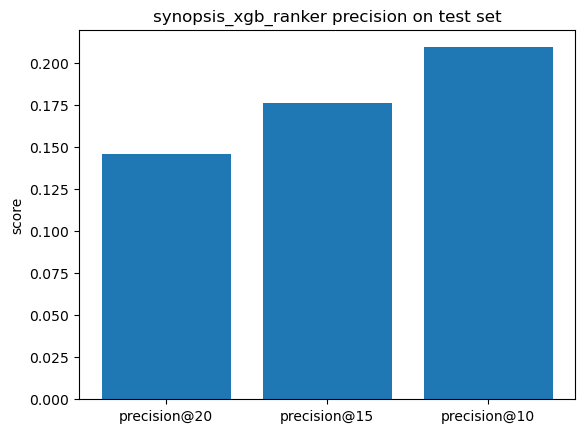

In [40]:
plt.bar(['precision@20', 'precision@15', 'precision@10'],
    [model_results['synopsis_xgb_ranker'][n] for n in ['precision@20', 'precision@15', 'precision@10']]
)
plt.ylabel('score')
plt.title('synopsis_xgb_ranker precision on test set')
plt.show()

Now we'll test what happens if we drop all the rows with n/a entries.

In [52]:
dropna_results = dict()

In [ ]:
numerical_features = ["Total_Awards_Previously", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features
synopsis_features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features + ['encoded_synopsis'] # actually not needed in the model


y_true = test_set2['target']

# dummy classifier


dummy_pred2 = dummy_classifier.predict(test_set2[features])

from sklearn.metrics import confusion_matrix

dropna_results['dummy_classifier'] = {
    'f1_score': f1_score(y_true, dummy_pred2),
    'precision': precision_score(y_true, dummy_pred2),
    'recall': recall_score(y_true, dummy_pred2),
    'cm' : confusion_matrix(y_true, dummy_pred2, normalize='true')
    # add more
}

# previous nomination classifier

nom_pred2 = (test_set2['NomineeBefore']).astype(int)

dropna_results['prior_nomination_baseline'] = {
    'f1_score': f1_score(y_true, nom_pred2),
    'precision': precision_score(y_true, nom_pred2),
    'recall': recall_score(y_true, nom_pred2),
    'cm' : confusion_matrix(y_true, nom_pred2, normalize='true')
    # add more
}

# logistic regression

books_test_log2 = test_set2.copy()
books_test_log2['years_since_last_nomination'] = books_test_log2['years_since_last_nomination'].fillna(99)
books_test_log2['month_of_publication'] = books_test_log2['month_of_publication'].fillna('Unknown')

logistic_proba = logistic_reg.predict_proba(books_test_log2[features])[:, 1]

# recover the weighted mean threshold to use for classification: 
thresholds = logistic_reg.cv_results_['thresholds']
scores = logistic_reg.cv_results_['scores']

weighted_mean_threshold = np.average(thresholds, weights=scores)

logistic_pred = (logistic_proba > weighted_mean_threshold).astype(int)

dropna_results['logistic_reg'] = {
    'f1_score': f1_score(y_true, logistic_pred),
    'precision': precision_score(y_true, logistic_pred),
    'recall': recall_score(y_true, logistic_pred),
    'cm' : confusion_matrix(y_true, logistic_pred, normalize='true')
    # add more
}

# xgb_classifier
numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]


features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_predict = xgbclassifier.predict(test_set2[features])

dropna_results['xgb_classifier'] = {
    'f1_score': f1_score(y_true, xgb_predict),
    'precision': precision_score(y_true, xgb_predict),
    'recall': recall_score(y_true, xgb_predict),
    'cm' : confusion_matrix(y_true, xgb_predict, normalize='true')
    # add more
}

# xgb_ranker
numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

xgb_rank_set = test_set2.copy()

xgb_ranking2 = xgbranker.predict(test_set2[features])


xgb_rank_set['xgb_rank_score'] = xgb_ranking2

xgb_rank_set['rank_within_year'] = xgb_rank_set.groupby('release_year')['xgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (xgb_rank_set['rank_within_year'] <= num_finalists).astype(int)
top10 = (xgb_rank_set['rank_within_year'] <= 10).astype(int)
top15 = (xgb_rank_set['rank_within_year'] <= 15).astype(int)
top20 = (xgb_rank_set['rank_within_year'] <= 20).astype(int)
top100 = (xgb_rank_set['rank_within_year'] <= 100).astype(int)

dropna_results['xgb_ranker'] = {
    'f1_score': f1_score(y_true, topk),
    'precision': precision_score(y_true, topk),
    'recall': recall_score(y_true, topk),
    'precision@10': precision_score(y_true, top10),
    'precision@15': precision_score(y_true, top15),
    'precision@20': precision_score(y_true, top20),
    'cm' : confusion_matrix(y_true, topk, normalize='true')
    # add more
}

# lgbm model
numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

lgb_ranking = lgbmranker.predict(test_set2[features])

test_set2['lgb_rank_score'] = lgb_ranking

test_set2['lgb_rank_within_year'] = test_set2.groupby('release_year')['lgb_rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (test_set2['lgb_rank_within_year'] <= num_finalists).astype(int)
top10 = (test_set2['lgb_rank_within_year'] <= 10).astype(int)
top15 = (test_set2['lgb_rank_within_year'] <= 15).astype(int)
top20 = (test_set2['lgb_rank_within_year'] <= 20).astype(int)


dropna_results['lgbm_ranker'] = {
    'f1_score': f1_score(y_true, topk),
    'precision': precision_score(y_true, topk),
    'recall': recall_score(y_true, topk),
    'precision@10': precision_score(y_true, top10),
    'precision@15': precision_score(y_true, top15),
    'precision@20': precision_score(y_true, top20),
    'ndcg@k': mean_ndcg_at_k(test_set2, 'lgb_rank_score', num_finalists),
    'ndcg@10': mean_ndcg_at_k(test_set2, 'lgb_rank_score', 10),
    'ndcg@15': mean_ndcg_at_k(test_set2, 'lgb_rank_score', 15),
    'ndcg@20': mean_ndcg_at_k(test_set2, 'lgb_rank_score', 20),
    'cm' : confusion_matrix(y_true, topk, normalize='true')
    # add more
}

# synopsis_xgb_ranker model

numerical_features = ["Total_Awards_Previously", "Author_Age_at_Publication", "author_num_books", "years_since_last_nomination", "publisher_historical_nominations", "publisher_cohort_size"]
categorical_features = ["first_publisher", "month_of_publication"]
mlb_features = ["tags"]
bool_features = ["new_author"]

synopsis_features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features + ['encoded_synopsis'] # actually not needed in the model

synopsis_ranking = synopsis_xgb.predict(test_set2[synopsis_features]) # we can actually just plug in books_test here because the model pipeline drops all features on in the features list

synop_set = test_set2.copy()

# now we'll do the ranking system same as with xgb_ranker
synop_set['rank_score'] = synopsis_ranking

synop_set['rank_within_year'] = synop_set.groupby('release_year')['rank_score'].rank(
        method='first', 
        ascending=False
    )

# in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
# so, set number of finalists to 26 per year and mark top 26 books as correct
num_finalists = 26

topk = (synop_set['rank_within_year'] <= num_finalists).astype(int)
top10 = (synop_set['rank_within_year'] <= 10).astype(int)
top15 = (synop_set['rank_within_year'] <= 15).astype(int)
top20 = (synop_set['rank_within_year'] <= 20).astype(int)
top100 = (synop_set['rank_within_year'] <= 100).astype(int)



dropna_results['synopsis_xgb_ranker'] = {
    'f1_score': f1_score(y_true, topk),
    'precision': precision_score(y_true, topk),
    'recall': recall_score(y_true, topk),
    'precision@10': precision_score(y_true, top10),
    'precision@15': precision_score(y_true, top15),
    'precision@20': precision_score(y_true, top20),
    'cm' : confusion_matrix(y_true, topk, normalize='true')
    # add more if need
}

/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/tiger/anaconda3/envs/erdos_ds_environment/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMRanker was fitted with feature names
  warnings.warn(


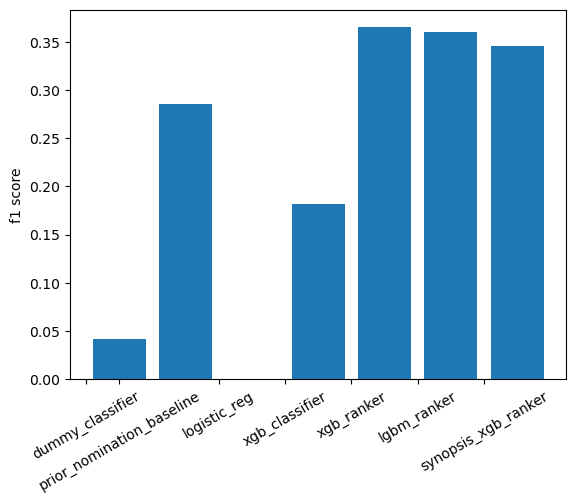

In [75]:
plt.bar(np.arange(len(dropna_results)), [model['f1_score'] for model in dropna_results.values()])
plt.ylabel('f1 score')
plt.xticks(np.arange(len(dropna_results)) - 0.5 - 0.5 * np.array([0, 1, 0, 0 ,0 ,0, 0]), dropna_results.keys(), rotation=30,)
plt.show()

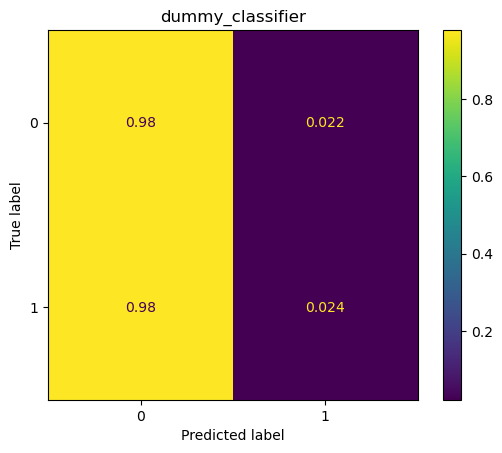

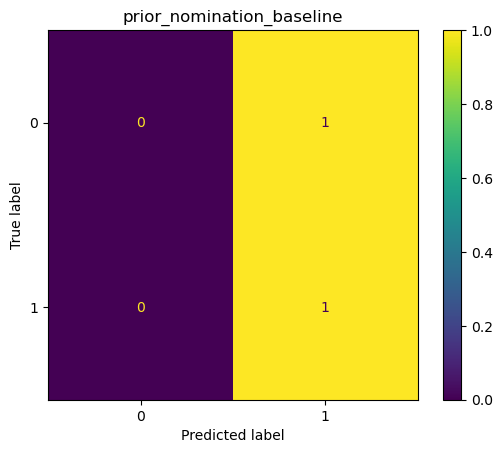

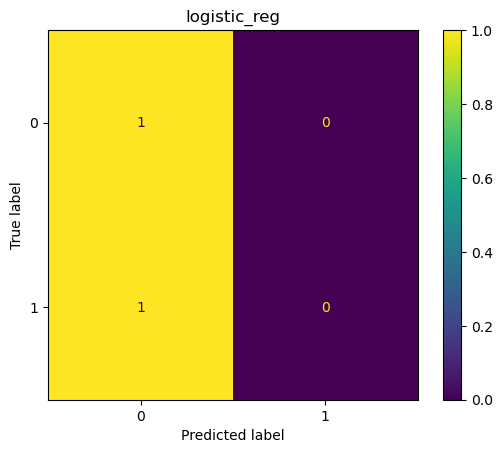

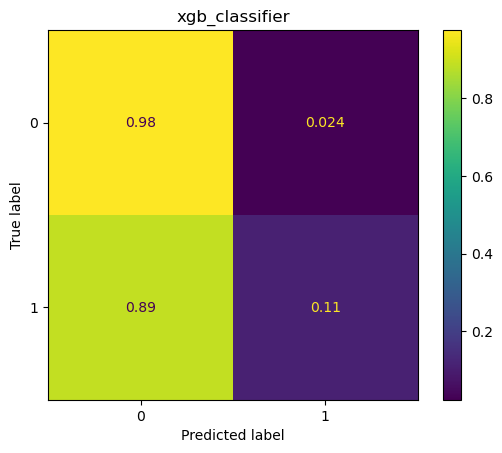

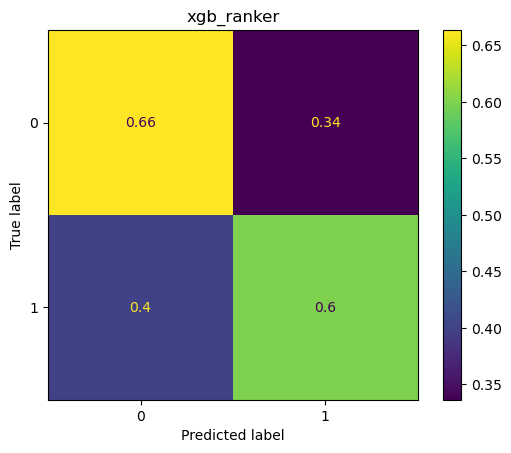

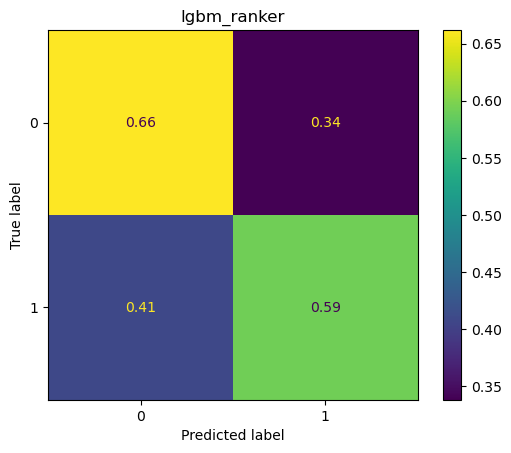

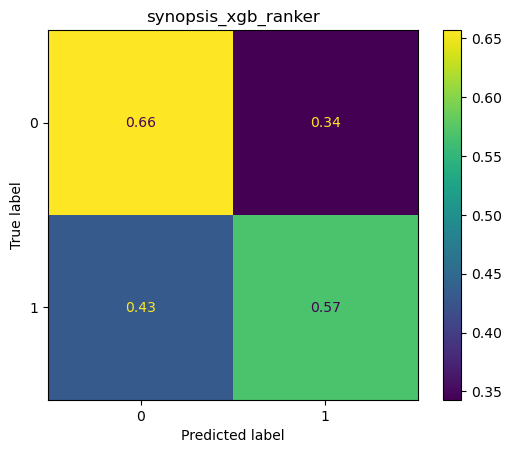

In [83]:
from sklearn.metrics import ConfusionMatrixDisplay

for model in dropna_results:
    ConfusionMatrixDisplay(dropna_results[model]['cm']).plot()
    plt.title(model)

    plt.show()

In [43]:
f1scores = []
years = []
features = numerical_features + categorical_features + list(tag_dataframe.columns) + ['release_year'] + bool_features

for year, group in books_test.groupby('release_year'):
    xgb_ranking = xgbranker.predict(group[features])

    group['xgb_rank_score'] = xgb_ranking

    group['rank_within_year'] = group.groupby('release_year')['xgb_rank_score'].rank(
            method='first', 
            ascending=False
        )

    # in recent years, each of the two Locus awards has 10 finalists published, and Hugo has 6
    # so, set number of finalists to 26 per year and mark top 26 books as correct
    num_finalists = 26

    topk = (group['rank_within_year'] <= num_finalists).astype(int)
    f1scores.append(f1_score(group['target'], topk))
    years.append(year)


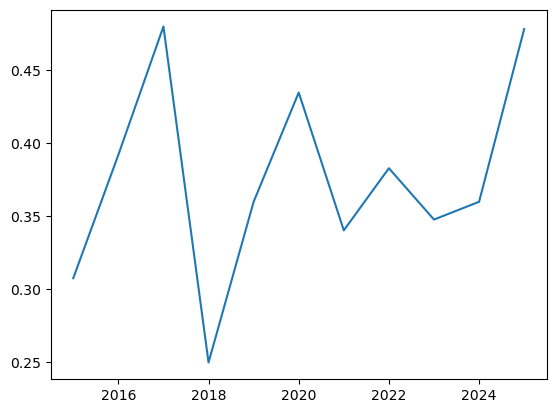

In [44]:
plt.plot(years, f1scores)

plt.show()

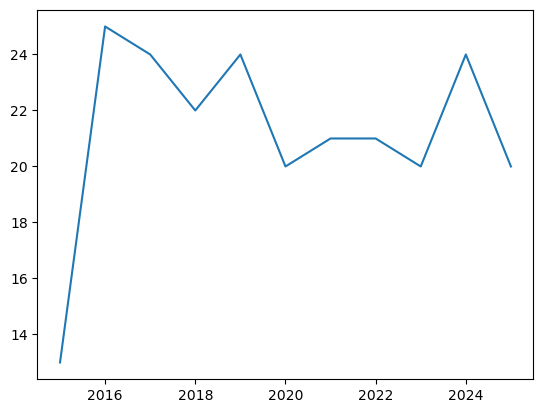

In [45]:
plt.plot(years, books_test.groupby('release_year')['target'].sum().values)
plt.show()

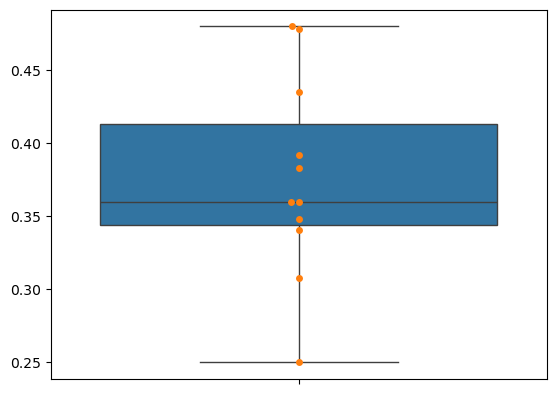

In [46]:
import seaborn as sns

ax = sns.boxplot(data=f1scores)

sns.swarmplot(data=f1scores)
plt.show()

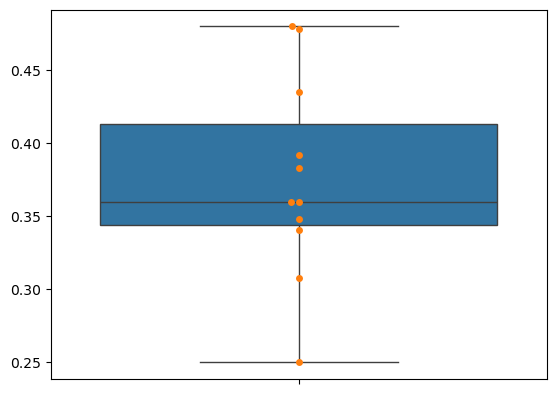

In [47]:
import seaborn as sns

ax = sns.boxplot(data=f1scores)

sns.swarmplot(data=f1scores)
plt.show()